# 3D Scene Understanding with SAM 3D Body

In [ ]:
!pip install rerun-sdk[notebook]==0.27.1

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
!git clone https://github.com/facebookresearch/sam-3d-body.git

Cloning into 'sam-3d-body'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 172 (delta 25), reused 12 (delta 12), pack-reused 97 (from 2)
Receiving objects: 100% (172/172), 22.39 MiB | 19.24 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [ ]:
!pip install pytorch-lightning pyrender opencv-python yacs scikit-image einops timm dill pandas rich hydra-core hydra-submitit-launcher hydra-colorlog pyrootutils webdataset chump networkx==3.2.1 roma joblib seaborn wandb appdirs appnope ffmpeg cython jsonlines pytest xtcocotools loguru optree fvcore black pycocotools tensorboard huggingface_hub
!pip install 'git+https://github.com/facebookresearch/detectron2.git@a1ce2f9' --no-build-isolation --no-deps
!pip install git+https://github.com/microsoft/MoGe.git

In [3]:
%cd sam-3d-body

/content/sam-3d-body


In [4]:
import sys
sys.path.append('/content/sam-3d-body')
sys.path.append('/content/sam-3d-body/notebook')
sys.path.append('/content/sam-3d-body/tools')
sys.path.append('/content/sam-3d-body/sam_3d_body')
sys.path.append('/content/sam-3d-body/sam_3d_body/metadata')

## **1.** Model

In [ ]:
import sys
import os

parent_dir = os.path.dirname(os.getcwd())
sys.path.insert(0, parent_dir)

from utils import (
    setup_sam_3d_body,
    setup_visualizer,
    visualize_2d_results,
    visualize_3d_mesh,
    save_mesh_results,
    display_results_grid,
    process_image_with_mask
)

# Set up SAM 3D Body estimator
estimator = setup_sam_3d_body(hf_repo_id="facebook/sam-3d-body-dinov3")
visualizer = setup_visualizer()

## **2.** Process Image

In [6]:
!wget -O image.png "https://chl-cloudinary.corebine.com/chl-production/image/upload/c_fill,dpr_3.0,f_webp,g_center,h_430,q_auto,w_768/v1/chl-prod/2025-09-04_ILV-RBS-105960-imag"

--2025-12-10 11:18:36--  https://chl-cloudinary.corebine.com/chl-production/image/upload/c_fill,dpr_3.0,f_webp,g_center,h_430,q_auto,w_768/v1/chl-prod/2025-09-04_ILV-RBS-105960-imag
Resolving chl-cloudinary.corebine.com (chl-cloudinary.corebine.com)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to chl-cloudinary.corebine.com (chl-cloudinary.corebine.com)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 320320 (313K) [image/webp]
Saving to: ‘image.png’

image.png           100%[===================>] 312.81K  --.-KB/s    in 0.02s   

2025-12-10 11:18:36 (13.8 MB/s) - ‘image.png’ saved [320320/320320]



Running object detector...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W1210 11:18:44.709000 1503 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Found boxes: [[1.1272573e+00 4.5336311e+01 1.8569260e+02 7.2522955e+02]
 [8.8853249e+01 7.6005417e+01 4.8496405e+02 7.9894012e+02]
 [3.7171283e+02 2.2590292e+02 1.0222527e+03 1.2234072e+03]
 [7.9979456e+02 1.6900749e+02 1.8096528e+03 1.1373479e+03]
 [1.4834445e+03 6.0758133e+00 2.1955786e+03 1.2703829e+03]]
Running FOV estimator ...
Number of people detected: 5
Output keys for first person: ['bbox', 'focal_length', 'pred_keypoints_3d', 'pred_keypoints_2d', 'pred_vertices', 'pred_cam_t', 'pred_pose_raw', 'global_rot', 'body_pose_params', 'hand_pose_params', 'scale_params', 'shape_params', 'expr_params', 'mask', 'pred_joint_coords', 'pred_global_rots', 'lhand_bbox', 'rhand_bbox']


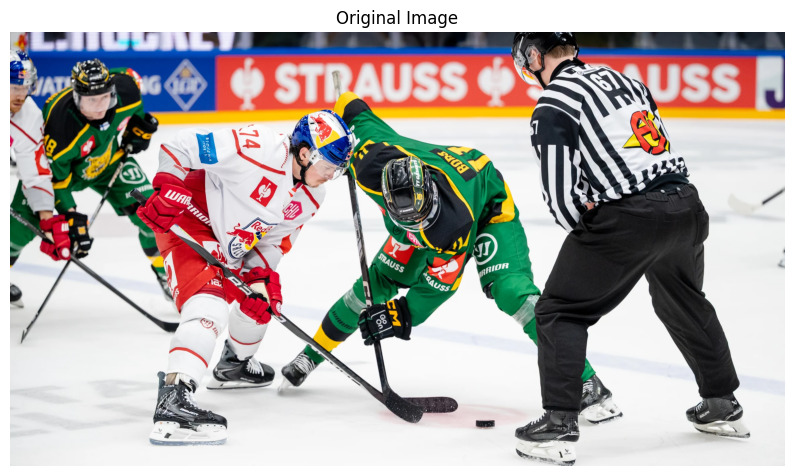

In [7]:
import cv2
import matplotlib.pyplot as plt

image_path = "image.png"
img_cv2 = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

outputs = estimator.process_one_image(image_path)

print(f"Number of people detected: {len(outputs)}")
if outputs:
    print(f"Output keys for first person: {list(outputs[0].keys())}")

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Original Image')
plt.show()

## **3.** 2D Visualization - Keypoints and Bounding Boxes

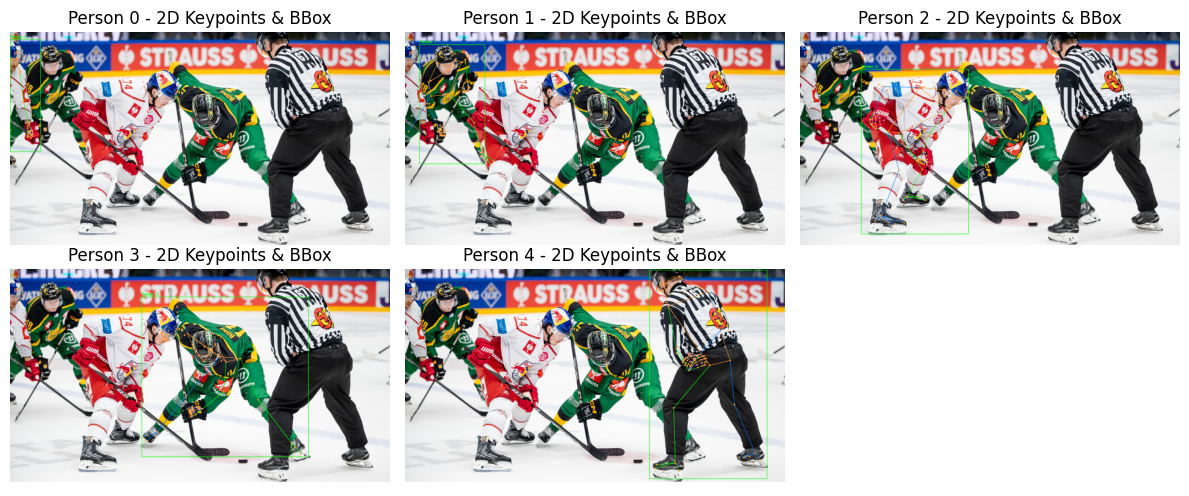

In [12]:
if outputs:
    vis_results = visualize_2d_results(img_cv2, outputs, visualizer)
    titles = [f'Person {i} - 2D Keypoints & BBox' for i in range(len(vis_results))]
    display_results_grid(vis_results, titles, figsize_per_image=(4, 2.5))
else:
    print("No people detected in the image")

## **4.** 3D Mesh Visualization - Overlay and Side View


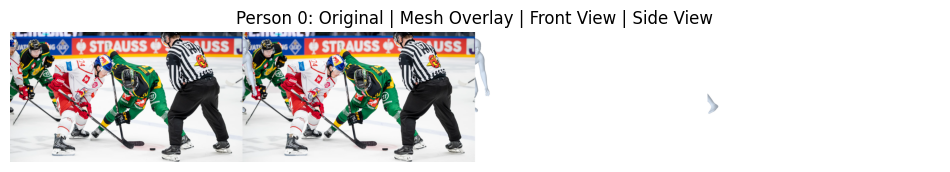

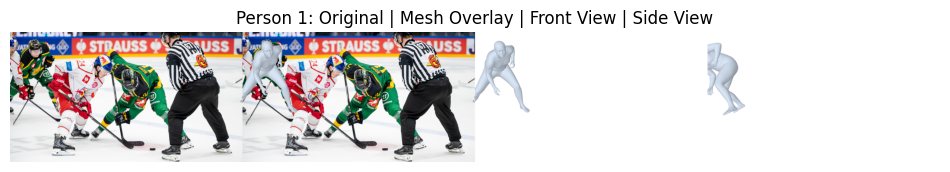

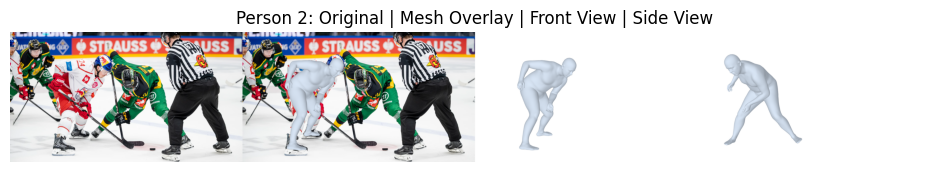

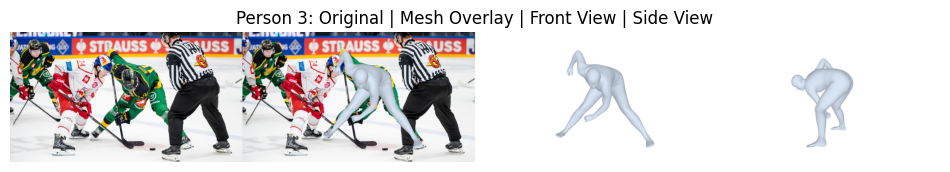

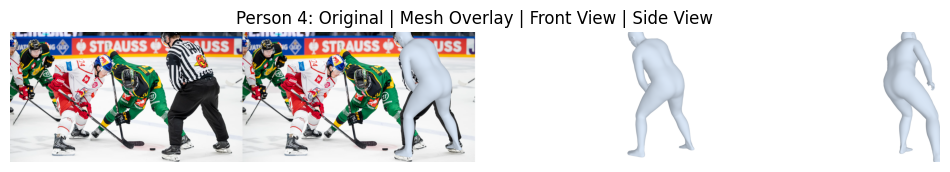

In [14]:
if outputs:
    mesh_results = visualize_3d_mesh(img_cv2, outputs, estimator.faces)
    for i, combined_img in enumerate(mesh_results):
        combined_rgb = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 3))
        plt.imshow(combined_rgb)
        plt.title(f'Person {i}: Original | Mesh Overlay | Front View | Side View')
        plt.axis('off')
        plt.show()
else:
    print("No people detected for 3D mesh visualization")

## **5.** Save 3D Mesh and Results


In [15]:
if outputs:
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    output_dir = f"output/{image_name}"

    # Save all results (PLY meshes, overlay images, bbox images)
    ply_files = save_mesh_results(img_cv2, outputs, estimator.faces, output_dir, image_name)
    print(f"Output directory: {output_dir}")
    print(f"Number of PLY files created: {len(ply_files)}")
else:
    print("No results to save - no people detected")

Saved focal length: output/image/image_focal_length.json
Saved mesh: output/image/image_mesh_000.ply
Saved overlay: output/image/image_overlay_000.png
Saved bbox: output/image/image_bbox_000.png
Saved mesh: output/image/image_mesh_001.ply
Saved overlay: output/image/image_overlay_001.png
Saved bbox: output/image/image_bbox_001.png
Saved mesh: output/image/image_mesh_002.ply
Saved overlay: output/image/image_overlay_002.png
Saved bbox: output/image/image_bbox_002.png
Saved mesh: output/image/image_mesh_003.ply
Saved overlay: output/image/image_overlay_003.png
Saved bbox: output/image/image_bbox_003.png
Saved mesh: output/image/image_mesh_004.ply
Saved overlay: output/image/image_overlay_004.png
Saved bbox: output/image/image_bbox_004.png
Output directory: output/image
Number of PLY files created: 5


## **6.** Rerun Interactive Visualization

Viz from: https://github.com/pablovela5620/sam3-rerun

In [16]:
from metadata.mhr70 import pose_info as _MHR70_POSE_INFO

# Derive IDs, names, and links from pose_info
#  Take the MHR-70 pose definition (a dictionary describing the 70 human keypoints and
#  the skeleton connections) and convert it into lookup tables used for viz.
MHR70_ID2NAME = {idx: info["name"] for idx, info in _MHR70_POSE_INFO["keypoint_info"].items()}
MHR70_IDS = sorted(MHR70_ID2NAME.keys())
_MHR70_NAME_TO_ID = {name: idx for idx, name in MHR70_ID2NAME.items()}
MHR70_LINKS = [
    (_MHR70_NAME_TO_ID[link_info["link"][0]], _MHR70_NAME_TO_ID[link_info["link"][1]])
    for link_info in _MHR70_POSE_INFO["skeleton_info"].values()
]


import numpy as np
import cv2
from pathlib import Path
import rerun as rr
import rerun.blueprint as rrb

# Color palette and constants
BOX_PALETTE = np.array([
        [255, 99, 71, 255],    # tomato
        [65, 105, 225, 255],   # royal blue
        [60, 179, 113, 255],   # medium sea green
        [255, 215, 0, 255],    # gold
        [138, 43, 226, 255],   # blue violet
        [255, 140, 0, 255],    # dark orange
        [220, 20, 60, 255],    # crimson
        [70, 130, 180, 255],   # steel blue
    ],
    dtype=np.uint8,
)

SEG_CLASS_OFFSET = 1000  # background = 1000, persons start at 1001


def filter_out_of_bounds(uv, h, w, xyz_cam=None):
    """
    Take a list of 2D keypoints (pixel coordinates) and replace the invalid ones, i.e.
    the ones that fall outside the image, with NaN so they don't get rendered in rerun
    """
    uv_filtered = np.asarray(uv, dtype=np.float32).copy()
    out_of_bounds = (uv_filtered[:, 0] >= float(w)) | (uv_filtered[:, 0] < 0.0)
    out_of_bounds |= (uv_filtered[:, 1] >= float(h)) | (uv_filtered[:, 1] < 0.0)
    if xyz_cam is not None:
        out_of_bounds |= (xyz_cam[:, 2] < 0.0)
    uv_filtered[out_of_bounds, :] = np.nan
    return uv_filtered


def compute_vertex_normals(verts, faces, eps: float = 1e-12):
    """
    Compute per-vertex normals for a 3D triangle mesh. A vertex normal is the average
    of the normals of all faces that touch that vertex, normalized to unit length.
    These are needed for proper shading in 3D (e.g. smooth lighting in rerun)
    """
    faces_i = faces.astype(np.int64)
    v0 = verts[faces_i[:, 0]]
    v1 = verts[faces_i[:, 1]]
    v2 = verts[faces_i[:, 2]]
    e1 = v1 - v0
    e2 = v2 - v0
    face_normals = np.cross(e1, e2)

    vertex_normals = np.zeros_like(verts, dtype=np.float32)
    flat_indices = faces_i.reshape(-1)
    face_normals_repeated = np.repeat(face_normals, 3, axis=0)
    np.add.at(vertex_normals, flat_indices, face_normals_repeated)

    norms = np.linalg.norm(vertex_normals, axis=-1, keepdims=True)
    denom = np.maximum(norms, eps).astype(np.float32)
    vn_unit = (vertex_normals / denom).astype(np.float32)
    mask = norms > eps
    vn_unit = np.where(mask, vn_unit, np.float32(0.0))
    return vn_unit


def rr_set_annotation_context():
    """Register MHR-70 keypoints & segmentation classes for Rerun."""
    person_class = rr.ClassDescription(
        info=rr.AnnotationInfo(id=0, label="Person", color=(0, 0, 255)),
        keypoint_annotations=[rr.AnnotationInfo(id=idx, label=name) for idx, name in MHR70_ID2NAME.items()],
        keypoint_connections=MHR70_LINKS,
    )
    seg_classes = [
        rr.ClassDescription(info=rr.AnnotationInfo(id=SEG_CLASS_OFFSET, label="Background", color=(64, 64, 64))),
    ]
    for idx, color in enumerate(BOX_PALETTE[:, :3].tolist(), start=1):
        seg_classes.append(
            rr.ClassDescription(
                info=rr.AnnotationInfo(
                    id=SEG_CLASS_OFFSET + idx,
                    label=f"Person-{idx}",
                    color=tuple(int(c) for c in color),
                ),
            )
        )
    rr.log("/", rr.AnnotationContext([person_class, *seg_classes]), static=True)


def rr_create_view():
    view_2d = rrb.Vertical(
        contents=[
            # Top: people-only overlay on the RGB image.
            rrb.Spatial2DView(
                name="image",
                origin="/world/cam/pinhole",
                contents=[
                    "/world/cam/pinhole/image",
                    "/world/cam/pinhole/pred/segmentation_overlay",
                ],
            ),
            # Bottom: 2D boxes + keypoints; segmentation hidden.
            rrb.Spatial2DView(
                name="mhr",
                origin="/world/cam/pinhole",
                contents=[
                    "/world/cam/pinhole/image",
                    "/world/cam/pinhole/pred/**",
                    "- /world/cam/pinhole/pred/segmentation_overlay/**",
                    "- /world/cam/pinhole/pred/segmentation_ids/**",
                ],
            ),
        ],
    )
    view_3d = rrb.Spatial3DView(name="mhr_3d", line_grid=rrb.LineGrid3D(visible=False))
    main_view = rrb.Horizontal(contents=[view_2d, view_3d], column_shares=[2, 3])
    return rrb.Tabs(contents=[main_view], name="sam-3d-body-demo")


def rr_visualize_sample(outputs, rgb_hw3, faces, parent_log_path=Path("/world")):
    """Log one image + predictions to Rerun."""
    if not outputs:
        return
    h, w = rgb_hw3.shape[:2]
    cam_log_path = parent_log_path / "cam"
    pinhole_log_path = cam_log_path / "pinhole"
    image_log_path = pinhole_log_path / "image"
    pred_log_path = pinhole_log_path / "pred"
    try:
        focal_length = float(np.asarray(outputs[0]["focal_length"]).reshape(()))
        rr.log(
            str(pinhole_log_path),
            rr.Pinhole(
                focal_length=focal_length,
                resolution=[int(w), int(h)],
            ),
        )
    except Exception:
        pass

    # Clear previous logs and log the RGB image
    rr.log(str(pred_log_path), rr.Clear(recursive=True))
    rr.log(str(image_log_path), rr.Image(rgb_hw3, color_model=rr.ColorModel.RGB).compress(jpeg_quality=90))

    seg_map = np.full((h, w), SEG_CLASS_OFFSET, dtype=np.int32)
    seg_overlay = np.zeros((h, w, 4), dtype=np.uint8)
    human_mask = np.zeros((h, w), dtype=bool)

    mesh_root_path = parent_log_path / "pred"
    rr.log(str(mesh_root_path), rr.Clear(recursive=True))

    faces_int = np.ascontiguousarray(faces, dtype=np.int32)

    for i, out in enumerate(outputs):
        box_color = BOX_PALETTE[i % len(BOX_PALETTE)].reshape(1, 4)

        # 2D bounding boxes
        rr.log(
            f"{pred_log_path}/bbox_{i}",
            rr.Boxes2D(
                array=np.asarray(out["bbox"]),
                array_format=rr.Box2DFormat.XYXY,
                class_ids=0,
                colors=box_color,
                show_labels=True,
            ),
        )

        # 2D keypoints
        kpts_cam = np.ascontiguousarray(out["pred_keypoints_3d"], dtype=np.float32)
        kpts_uv = np.ascontiguousarray(out["pred_keypoints_2d"], dtype=np.float32)
        kpts_uv_in_bounds = filter_out_of_bounds(kpts_uv, h=h, w=w, xyz_cam=None)
        rr.log(
            f"{pred_log_path}/uv_{i}",
            rr.Points2D(
                positions=kpts_uv_in_bounds,
                keypoint_ids=MHR70_IDS,
                class_ids=0,
                colors=(0, 255, 0),
            ),
        )

        # Optional segmentation mask -> segmentation overlay
        mask = out.get("mask", None)
        if mask is not None:
            mask_arr = np.asarray(mask).squeeze()
            if mask_arr.shape != seg_map.shape:
                mask_arr = cv2.resize(
                    mask_arr.astype(np.uint8),
                    (seg_map.shape[1], seg_map.shape[0]),
                    interpolation=cv2.INTER_NEAREST,
                )
            mask_bool = mask_arr.astype(bool)

        else:
            # Fallback: approximate segmentation from the bounding box so the
            # top-left view still shows per-person overlays even if masks
            # are not available.
            box = np.asarray(out["bbox"], dtype=float)
            x1, y1, x2, y2 = box
            x1 = int(max(0, min(w - 1, x1)))
            x2 = int(max(0, min(w, x2)))
            y1 = int(max(0, min(h - 1, y1)))
            y2 = int(max(0, min(h, y2)))
            mask_bool = np.zeros_like(seg_map, dtype=bool)
            if x2 > x1 and y2 > y1:
                mask_bool[y1:y2, x1:x2] = True

        human_mask[:] = np.logical_or(human_mask, mask_bool)
        seg_id = SEG_CLASS_OFFSET + i + 1
        seg_map = np.where(mask_bool, np.uint16(seg_id), seg_map)

        color = BOX_PALETTE[i % len(BOX_PALETTE), :3]
        seg_overlay[mask_bool] = np.array([color[0], color[1], color[2], 120], dtype=np.uint8)

        # 3D keypoints & mesh in world coordinates (camera at origin)
        cam_t = np.ascontiguousarray(out["pred_cam_t"], dtype=np.float32)
        kpts_world = np.ascontiguousarray(kpts_cam + cam_t, dtype=np.float32)
        rr.log(
            f"{parent_log_path}/pred/kpts3d_{i}",
            rr.Points3D(
                positions=kpts_world,
                keypoint_ids=MHR70_IDS,
                class_ids=0,
                colors=(0, 255, 0),
            ),
        )

        verts_cam = np.ascontiguousarray(out["pred_vertices"], dtype=np.float32)
        verts_world = np.ascontiguousarray(verts_cam + cam_t, dtype=np.float32)
        vertex_normals = compute_vertex_normals(verts_world, faces_int)
        rr.log(
            f"{parent_log_path}/pred/mesh_{i}",
            rr.Mesh3D(
                vertex_positions=verts_world,
                triangle_indices=faces_int,
                vertex_normals=vertex_normals,
                albedo_factor=(
                    float(box_color[0, 0]) / 255.0,
                    float(box_color[0, 1]) / 255.0,
                    float(box_color[0, 2]) / 255.0,
                    0.35,
                ),
            ),
        )

    # Log segmentation ids and RGBA overlay (transparent background)
    if np.any(seg_map != SEG_CLASS_OFFSET):
        rr.log(f"{pred_log_path}/segmentation_ids", rr.SegmentationImage(seg_map))
        rr.log(f"{pred_log_path}/segmentation_overlay", rr.Image(seg_overlay, color_model=rr.ColorModel.RGBA))


In [18]:
from pathlib import Path
import rerun as rr

# Initialize Rerun for in-notebook (no external viewer window)
rr.init("sam3d_body_notebook", spawn=False)

# Set up layout & annotation context to match the sam3-rerun demo
rr_set_annotation_context()
blueprint = rr_create_view()
rr.send_blueprint(blueprint)
rr.log("/", rr.ViewCoordinates.RDF, static=True)

# Log the current frame
parent_log_path = Path("/world")
rr.set_time(timeline="image_sequence", sequence=0)
rr_visualize_sample(outputs, img_rgb, faces=estimator.faces, parent_log_path=parent_log_path)

# Show the interactive Rerun viewer inline in the notebook
rr.notebook_show(blueprint=blueprint)

HTML(value='<div id="137d5507-da2d-4a6b-93b8-32cadce46996"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…